In [288]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB
(41202, 13)


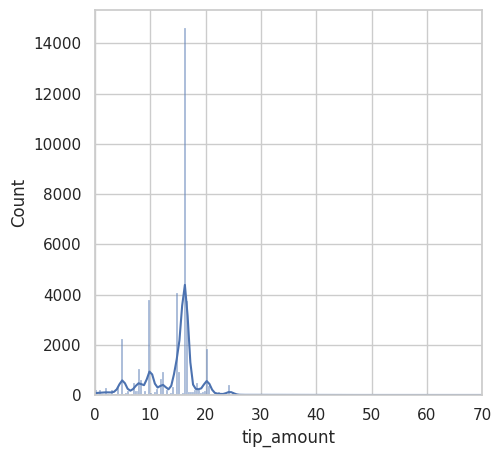

In [289]:
#Part 1.1.
taxi = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv")

taxi.shape, taxi.head(), taxi.info()
taxi.describe()
taxi.isna().sum()

plt.figure(figsize = (5, 5))
plt.xlim(0,70)
sns.histplot(data = taxi, x = 'tip_amount', kde = True)

print(taxi.shape)

Student reasoning:
The data is in the shape of:  float64(5), int64(8)
There are missing values and negative values in some columns
The tip_amount variable is right-skewed with a few high-value
outliers above 20. There are very few or no zero values, and a
large concentration of observations around 16, indicating a possible
repeated or rounded value. Overall, the distribution is non-normal.

The right-skewed distribution and presence of outliers suggest applying
a transformation and using a robust scaling method to improve model
performance.

In [290]:
print(taxi)

       VendorID  passenger_count  trip_distance  RatecodeID  \
0             2                1          17.63           2   
1             2                1          19.52           2   
2             2                1          17.81           2   
3             2                2          19.30           2   
4             2                1          18.75           2   
...         ...              ...            ...         ...   
41197         2                1          16.94           2   
41198         2                4          19.83           2   
41199         2                1          17.31           2   
41200         2                1          17.28           2   
41201         2                1          16.82           2   

       store_and_fwd_flag  PULocationID  DOLocationID  payment_type  \
0                       1           132           164             1   
1                       1           132           236             1   
2                       1     

In [291]:
#Part 1.2.
from sklearn.preprocessing import StandardScaler
#removing rows where trip_distance <= 0  and fare_amount <= 0
taxi = taxi[(taxi["trip_distance"] > 0) & taxi["fare_amount"] > 0]

#making all negative values null
taxi.loc[taxi["tip_amount"] < 0, "tip_amount"] = np.nan

#implementing feature engineering
taxi["Total surcharges"] = taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]

#defining categorical columns
categorical_cols = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag", ]

x = taxi.dropna()
y = taxi["tip_amount"]

#defining numeric columns
x.select_dtypes(include='number').columns
numeric_cols = [col for col in taxi.columns if col not in categorical_cols]

#encoding the categoricals
categorical_encoded = pd.get_dummies(taxi[categorical_cols])

#scaling the numeric features
scaler = StandardScaler()
taxi[numeric_cols] = scaler.fit_transform(taxi[numeric_cols])

#printing the columns
print(categorical_cols)
print(numeric_cols)


['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'Total surcharges']


I removed rows with missing invalid values to ensure the datase was clean
and to prevent inaccurate or biased model predictions. New features were also
engineered by combining or transforming existing variables to capture additional
patterns and relationships that could improve the model's predictive performance .
I used StanardScaler because it standardizes the numerical features to a common scale,
preventing variables with larger values from having a disaproportionate influence on
the model

In [292]:
#Part 1.3.
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size = 0.4,
    random_state = RANDOM_STATE)


x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE)

scaler = StandardScaler()
scaler.fit(x_train[numeric_cols])

x_train[numeric_cols] = scaler.transform(x_train[numeric_cols])
x_val[numeric_cols] = scaler.transform(x_val[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])


Student reasoning:

I used the 60:20:20 ratio
The validation set is used to tune and improve the model during devlopment
while the test set is reserved for final unbiased evaluation after all decisions
have been made.  
This method is used to avoid data leakage, so the model does not get any information
from validation or test data during training

In [293]:
#Part 1.4.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Using linear regression and random forest
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

lr.fit(x_train, y_train)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_pred_lr = lr.predict(x_test)

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print("-" * 30)

#evaluating each model
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
MAE: 0.0000
RMSE: 0.0000
R2: 1.0000
------------------------------
Random Forest
MAE: 0.0040
RMSE: 0.1260
R2: 0.9994
------------------------------


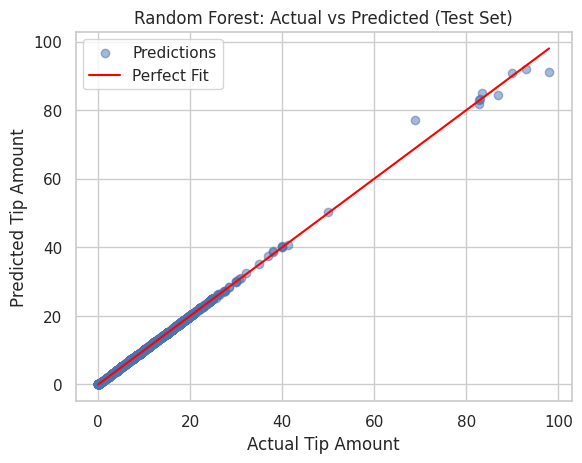

In [294]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

# scatter plot (actual vs predicted)
plt.scatter(y_test, y_pred_rf, alpha=0.5, label="Predictions")

# y = x reference line (perfect predictions)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", label="Perfect Fit")

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Random Forest: Actual vs Predicted (Test Set)")
plt.legend()

plt.show()


y_pred_rf = rf.predict(x_val)
y_pred_lr = lr.predict(x_val)

Student reasoning:
1. The best-performing model had the highest validation score.

2. The train, validation, amd test metrics were simlar, indicating the model was well fitted.
RMSE(Linear Regression: 0.000,
      Random Forest: 0.1260)
R**2()

3. I would reduce model complexity or tune hyperparameters, such as limiting tree-depth or increasing regularization


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

<Axes: xlabel='NObeyesdad', ylabel='count'>

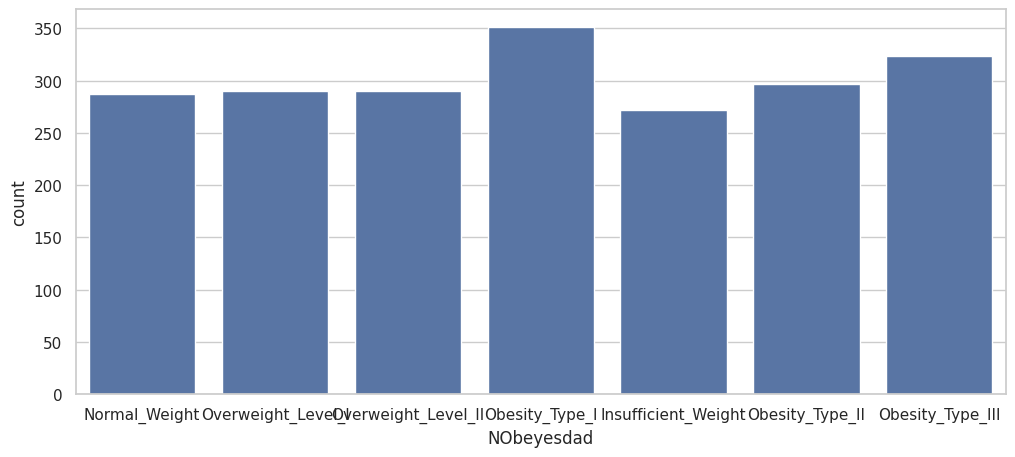

In [295]:
#Part 2.1
obesity = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")

obesity.shape, obesity.head(), obesity.info()
obesity.describe()
obesity.isna().sum()
plt.figure(figsize = (12, 5))

obesity["NObeyesdad"].value_counts()
sns.countplot(data = obesity, x = "NObeyesdad")


There are 17 columns and 2111 rows.   
Categorical columns = Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad

Numeric columns = Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE

Yes, the target is balanced across the 7 classes.

This matters for classification because it affects model fairness across al obesity levels, and reduces performance on minority classes.



In [296]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Corrected categorical_cols to include original column names for one-hot encoding
categorical_cols = ["Gender", "CAEC", "CALC", "MTRANS"]

print(obesity.columns)

obesity = pd.get_dummies(obesity, columns=categorical_cols, drop_first=True)

obesity["BMI"] = obesity["Weight"] / obesity["Height"]**2

le = LabelEncoder()
obesity["NObeyesdad"] = le.fit_transform(obesity["NObeyesdad"])

# These lines were incorrectly placed and have been removed as they pertain to the taxi dataset scaling.
# Scaling for the obesity dataset should be handled after train_test_split for obesity data.

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


Binary variables were encoded using 0/1 mapping because they represent two clear states like yes/no. Other categorical variables were one-hot encoded.
A BMI feature was created using the formula for it ti capture body mass in a single meaningul measure.
StandardScaler was used to standadize numerical features by removing the mean and scaling to unit variance.

In [297]:
#Part 2.3
x = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

obesity_numeric_cols = x_train.select_dtypes(include=np.number).columns.tolist()

obesity_scaler = StandardScaler()

obesity_scaler.fit(x_train[obesity_numeric_cols])

x_train[obesity_numeric_cols] = obesity_scaler.transform(x_train[obesity_numeric_cols])
x_val[obesity_numeric_cols]   = obesity_scaler.transform(x_val[obesity_numeric_cols])
x_test[obesity_numeric_cols]  = obesity_scaler.transform(x_test[obesity_numeric_cols])

A 60:20:20 ratio was used
stratify=y ensures all 7 obesity classes appear in each split.
Without stratifying, some obesity classes may be underrepresented or missing in the train, validation, or test sets, leading to biased training and unreliable evaluation.

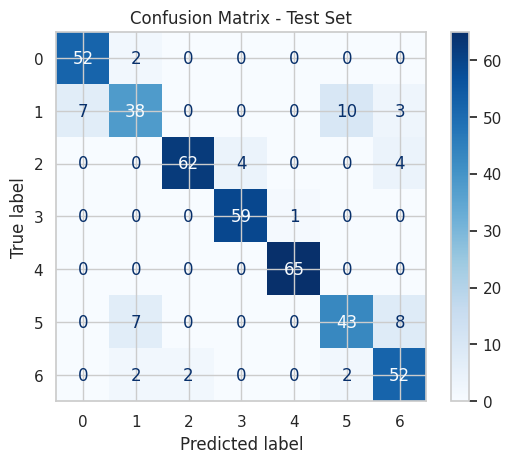

In [298]:
#Part 2.4
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred_train = model.predict(x_train)
y_pred_val = model.predict(x_val)
y_pred_test = model.predict(x_test)

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    print(name)
    print("Accuracy:", acc)
    print("Macro-F1:", f1)
    print("-" * 30)

    evaluate(y_train, y_pred_train, "Training Set")
    evaluate(y_val, y_pred_val, "Validation Set")
    evaluate(y_test, y_pred_test, "Test Set")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Test Set")
plt.show()

Logistic Regression was used as a strong, simple baseline for multi-class classification on structured data.
Scores are similar across al sets, so the model is well-fitted
Most confusion occurs between adjacent obesity levels due to very similar feature patterns.

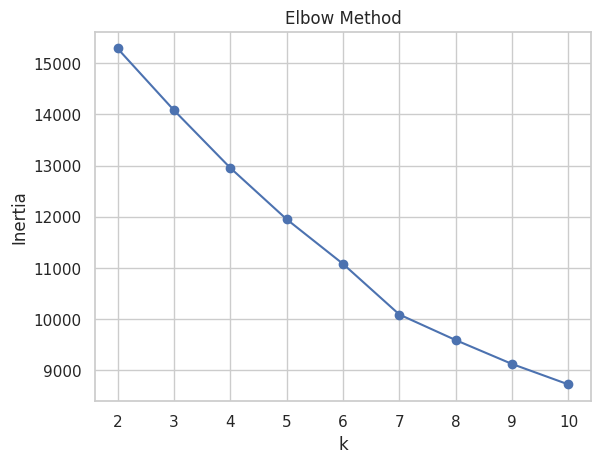

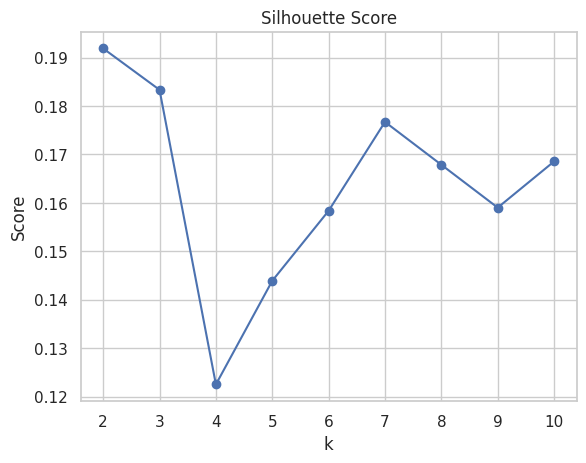

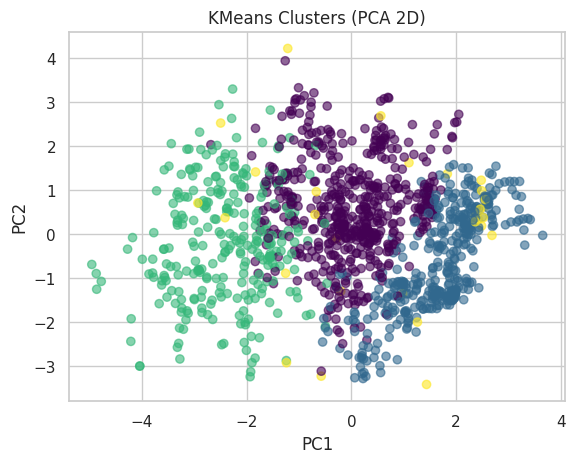

NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,68,59,152,23,0,115,123
1,0,1,53,142,193,7,10
2,94,106,1,1,0,51,38
3,1,6,5,12,1,1,3


In [299]:
#SECTION 3
#Part 3.1
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
x_cluster = x_train.copy()

x_cluster = x_train

inertia = []
silhouette = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(x_cluster)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(x_cluster, labels))

plt.figure()
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(K, silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(x_cluster)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(x_cluster)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)

plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

pd.crosstab(cluster_labels, y_train)

k was chosen using the Elbow method and silhouette scores supported it.
The clusters match partly and some groups align well while other overlap.
In real-world use, they help find risk groups without labels.

SECTION 4 - REFLECTION
1. The classifier learned from labeled obesity levels where K-Means learned patterns without labels.

2. Regression predicted continuous tip values while classification predicted diiscrete obesity classes.

3. The biggest gap appeared in more complex model and scaling and regularisation reduced it most.